# 🔬 Quantum Binary Fake News Detector v1.0
## Production-Ready Binary Classification


## Cell 1: Install & Import Everything

In [3]:
# Remove conflicting packages
!pip uninstall -y torch torchvision torchaudio transformers pennylane huggingface_hub accelerate peft sentence-transformers -q

# Install compatible versions
!pip install torch==2.3.0 torchvision==0.18.0 torchaudio==2.3.0 -q
!pip install transformers==4.41.2 huggingface_hub==0.23.2 -q
!pip install pennylane==0.36.0 pennylane-lightning==0.36.0 -q

# Other libraries
!pip install scikit-learn pandas numpy matplotlib seaborn tqdm -q

print("✅ All compatible packages installed")

ERROR: Operation cancelled by user
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 779.1/779.1 MB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 37.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 55.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 41.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 28.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 33.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 731.7/731.7 MB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 MB 14.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.2/124.2 MB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.0/196.0 MB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━

In [4]:
!pip uninstall -y pennylane autoray -q

!pip install autoray==0.6.3 -q
!pip install pennylane==0.36.0 pennylane-lightning==0.36.0 -q

In [1]:
import torch
import transformers
import pennylane as qml
import autoray

print("Torch:", torch.__version__)
print("Transformers:", transformers.__version__)
print("PennyLane:", qml.__version__)
print("Autoray:", autoray.__version__)
print("CUDA:", torch.cuda.is_available())

Torch: 2.3.0+cu121
Transformers: 4.41.2
PennyLane: 0.36.0
Autoray: 0.6.3
CUDA: True


## Cell 2: Configuration & Constants

In [2]:
from dataclasses import dataclass
from pathlib import Path

@dataclass
class Config:
    """Binary classification configuration"""
    # Random seed
    SEED: int = 42

    # Dataset
    MAX_LEN: int = 64
    NUM_CLASSES: int = 2  # Binary: Real(0) vs Fake(1)

    # Model
    ENCODER_MODEL: str = 'distilbert-base-uncased'
    HIDDEN_DIM: int = 768
    INTERMEDIATE_DIM: int = 512
    DROPOUT_RATE: float = 0.3
    LABEL_SMOOTHING: float = 0.1

    # Quantum (optimized for binary!)
    N_QUBITS: int = 6  # Less qubits for binary (2^6=64 is enough)
    N_QUANTUM_LAYERS: int = 2  # Fewer layers for binary
    QUANTUM_FEATURES: int = 64

    # Training
    BATCH_SIZE: int = 16
    VAL_SPLIT: float = 0.15
    TEST_SPLIT: float = 0.15
    NUM_EPOCHS: int = 30  # Fewer epochs for binary
    WARMUP_STEPS: int = 500

    # Learning Rates
    LR_ENCODER: float = 2e-5
    LR_HEAD: float = 5e-4

    # Regularization
    WEIGHT_DECAY: float = 1e-4
    MAX_GRAD_NORM: float = 1.0

    # Loss (Binary-specific)
    USE_FOCAL_LOSS: bool = True
    FOCAL_ALPHA: float = 0.25
    FOCAL_GAMMA: float = 2.0

    # Early Stopping
    EARLY_STOPPING_PATIENCE: int = 4
    EARLY_STOPPING_METRIC: str = 'f1'

    # Cross-Validation
    N_SPLITS: int = 5

    # Output
    SAVE_DIR: str = './results_binary'

config = Config()
Path(config.SAVE_DIR).mkdir(exist_ok=True)

print("✅ Configuration loaded")
print(f"   Encoder: {config.ENCODER_MODEL}")
print(f"   Binary classes: {config.NUM_CLASSES}")
print(f"   Quantum qubits: {config.N_QUBITS}")

✅ Configuration loaded
   Encoder: distilbert-base-uncased
   Binary classes: 2
   Quantum qubits: 6


## Cell 3: Reproducibility

In [3]:
import random
import numpy as np
import torch
import os

def set_seeds(seed: int = 42):
    """Set all seeds for reproducibility"""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seeds(config.SEED)
print(f"✅ All seeds set to {config.SEED}")

✅ All seeds set to 42


## Cell 4: Load Binary Dataset

In [4]:
import pandas as pd
import numpy as np

print(" Loading LIAR dataset...")

train_path = "/content/liar2_train.csv"
val_path   = "/content/liar2_validation.csv"
test_path  = "/content/liar2_test.csv"

# Load CSVs
df_train = pd.read_csv(train_path)
df_val   = pd.read_csv(val_path)
df_test  = pd.read_csv(test_path)

print(" Dataset loaded")
print(f"Train: {len(df_train)}")
print(f"Validation: {len(df_val)}")
print(f"Test: {len(df_test)}")

 Loading LIAR dataset...
 Dataset loaded
Train: 18369
Validation: 2297
Test: 2296


In [5]:
print(df_train["label"].unique())

[5 1 0 4 2 3]


In [6]:
# LABEL MAPPING:
# 0 = pants-fire
# 1 = false
# 2 = barely-true
# 3 = half-true
# 4 = mostly-true
# 5 = true

fake_labels = [0, 1, 2]
real_labels = [3, 4, 5]


def convert_to_binary(label):

    if label in fake_labels:
        return 1   # Fake

    elif label in real_labels:
        return 0   # Real

    else:
        return np.nan


# Apply conversion
df_train["binary_label"] = df_train["label"].apply(convert_to_binary)
df_val["binary_label"]   = df_val["label"].apply(convert_to_binary)
df_test["binary_label"]  = df_test["label"].apply(convert_to_binary)


# Remove invalid rows
df_train = df_train.dropna(subset=["binary_label"])
df_val   = df_val.dropna(subset=["binary_label"])
df_test  = df_test.dropna(subset=["binary_label"])


# Convert to int
df_train["binary_label"] = df_train["binary_label"].astype(int)
df_val["binary_label"]   = df_val["binary_label"].astype(int)
df_test["binary_label"]  = df_test["binary_label"].astype(int)


print(" Binary conversion complete")

print("\n TRAIN DISTRIBUTION")
print(df_train["binary_label"].value_counts())

print("\n VALIDATION DISTRIBUTION")
print(df_val["binary_label"].value_counts())

print("\n TEST DISTRIBUTION")
print(df_test["binary_label"].value_counts())

 Binary conversion complete

 TRAIN DISTRIBUTION
binary_label
1    10591
0     7778
Name: count, dtype: int64

 VALIDATION DISTRIBUTION
binary_label
1    1325
0     972
Name: count, dtype: int64

 TEST DISTRIBUTION
binary_label
1    1323
0     973
Name: count, dtype: int64


In [7]:
train_texts = df_train["statement"].astype(str).tolist()
train_labels = df_train["binary_label"].tolist()

val_texts = df_val["statement"].astype(str).tolist()
val_labels = df_val["binary_label"].tolist()

test_texts = df_test["statement"].astype(str).tolist()
test_labels = df_test["binary_label"].tolist()

print(" Text extraction complete")
print(f"Train samples: {len(train_texts)}")

 Text extraction complete
Train samples: 18369


In [8]:
import torch
from typing import List
from torch.utils.data import Dataset
from transformers import AutoTokenizer # Import AutoTokenizer

# Initialize tokenizer
tokenizer = AutoTokenizer.from_pretrained(config.ENCODER_MODEL)
print(f" Tokenizer loaded: {config.ENCODER_MODEL}")

class FakeNewsDataset(Dataset):
    """Binary fake news dataset"""

    def __init__(self, texts: List[str], labels: List[int], tokenizer, max_len: int = 256):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len
        assert len(texts) == len(labels), "Length mismatch!"

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx]).strip()
        label = int(self.labels[idx])

        encoding = self.tokenizer(
            text,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze(),
            'label': torch.tensor(label, dtype=torch.long)
        }

train_dataset = FakeNewsDataset(
    train_texts,
    train_labels,
    tokenizer,
    config.MAX_LEN
)

val_dataset = FakeNewsDataset(
    val_texts,
    val_labels,
    tokenizer,
    config.MAX_LEN
)

test_dataset = FakeNewsDataset(
    test_texts,
    test_labels,
    tokenizer,
    config.MAX_LEN
)
print(" Datasets created")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_token.py:89: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

 Tokenizer loaded: distilbert-base-uncased
 Datasets created


## Cell 5: Loss Functions

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class BinaryFocalLoss(nn.Module):
    """Focal Loss for binary classification"""

    def __init__(self, alpha: float = 0.25, gamma: float = 2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        # Binary cross entropy with logits
        # Ensure logits and targets have the same shape [B, 1]
        bce = F.binary_cross_entropy_with_logits(
            logits, targets, reduction='none'
        )

        # Get probabilities (logits is [B, 1])
        p = torch.sigmoid(logits)
        p_t = torch.where(targets == 1, p, 1 - p)

        # Focal term
        focal_weight = (1 - p_t) ** self.gamma
        focal_loss = self.alpha * focal_weight * bce

        return focal_loss.mean()

def get_loss_function(config: Config):
    if config.USE_FOCAL_LOSS:
        return BinaryFocalLoss(
            alpha=config.FOCAL_ALPHA,
            gamma=config.FOCAL_GAMMA
        )
    else:
        return nn.BCEWithLogitsLoss()

print(" Loss functions defined")

## Cell 6: Quantum Circuit for Binary

In [10]:
class BinaryQuantumCircuit(nn.Module):
    """Quantum circuit optimized for binary classification

    For binary problems:
    - Need fewer qubits (6 instead of 8)
    - Fewer layers (2 instead of 3)
    - Simpler but more effective
    """

    def __init__(self, n_qubits: int = 6, n_layers: int = 2,
                 input_dim: int = 768, output_dim: int = 64):
        super().__init__()
        self.n_qubits = n_qubits
        self.n_layers = n_layers

        # Preprocess to qubit count
        self.preprocess = nn.Sequential(
            nn.Linear(input_dim, n_qubits * 2),
            nn.LayerNorm(n_qubits * 2),
            nn.ReLU(),
            nn.Linear(n_qubits * 2, n_qubits)
        )

        # Quantum device
        self.dev = qml.device('default.qubit', wires=n_qubits)

        # Quantum weights
        n_weights = n_qubits * n_layers * 3
        self.quantum_weights = nn.Parameter(
            torch.randn(n_weights) * 0.1
        )

        # Define QNode with torch interface
        self.qnode_torch = qml.QNode(self.circuit, self.dev, interface='torch')

        # Postprocess
        self.postprocess = nn.Sequential(
            nn.Linear(n_qubits, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, output_dim)
        )

    def circuit(self, inputs: torch.Tensor, weights: torch.Tensor):
        # Encode input
        for i in range(self.n_qubits):
            qml.RY(inputs[i], wires=i)

        # Variational layers (simplified for binary)
        weight_idx = 0
        for layer in range(self.n_layers):
            # Rotation layer
            for i in range(self.n_qubits):
                qml.RX(weights[weight_idx], wires=i)
                weight_idx += 1
                qml.RY(weights[weight_idx], wires=i)
                weight_idx += 1
                qml.RZ(weights[weight_idx], wires=i)
                weight_idx += 1

            # Entanglement (linear chain for efficiency)
            for i in range(self.n_qubits - 1):
                qml.CNOT(wires=[i, i + 1])

        # Measure all
        return [qml.expval(qml.PauliZ(i)) for i in range(self.n_qubits)]

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        batch_size = x.shape[0]

        # Preprocess
        x_prep = self.preprocess(x).float()

        quantum_outputs = []

        for i in range(batch_size):

            # Ensure float32
            q_input = x_prep[i].float()
            q_weights = self.quantum_weights.float()

            # Quantum forward
            raw_output = self.qnode_torch(q_input, q_weights)

            # Convert tuple/list -> tensor
            output = torch.stack([r.float() for r in raw_output]).to(x.device)

            quantum_outputs.append(output)

        # Stack batch
        quantum_outputs = torch.stack(quantum_outputs, dim=0)

        # FORCE float32
        quantum_outputs = quantum_outputs.float()

        # Postprocess
        output = self.postprocess(quantum_outputs)

        return output

print(" Binary quantum circuit defined")

 Binary quantum circuit defined


## Cell 7: Model Architecture

In [11]:
import torch
import torch.nn as nn
from transformers import AutoModel

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

class BinaryQuantumFakeNewsDetector(nn.Module):
    """Binary classification model: Real vs Fake news"""

    def __init__(self, config: Config):
        super().__init__()
        self.config = config

        # Encoder
        self.encoder = AutoModel.from_pretrained(
            config.ENCODER_MODEL,
            trust_remote_code=True
        )
        self.encoder.gradient_checkpointing_enable()
        self.encoder_dim = self.encoder.config.hidden_size

        # Quantum circuit
        self.quantum = BinaryQuantumCircuit(
            n_qubits=config.N_QUBITS,
            n_layers=config.N_QUANTUM_LAYERS,
            input_dim=self.encoder_dim,
            output_dim=config.QUANTUM_FEATURES
        )

        # Feature fusion
        fused_dim = self.encoder_dim + config.QUANTUM_FEATURES

        self.fusion_bn = nn.BatchNorm1d(fused_dim)

        # Attention pooling
        self.attention = nn.Sequential(
            nn.Linear(fused_dim, fused_dim // 2),
            nn.ReLU(),
            nn.Dropout(config.DROPOUT_RATE),
            nn.Linear(fused_dim // 2, 1),
            nn.Sigmoid()
        )

        # Binary classifier head
        self.classifier = nn.Sequential(
            nn.Linear(fused_dim, config.INTERMEDIATE_DIM),
            nn.ReLU(),
            nn.BatchNorm1d(config.INTERMEDIATE_DIM),
            nn.Dropout(config.DROPOUT_RATE),

            nn.Linear(config.INTERMEDIATE_DIM, config.INTERMEDIATE_DIM // 2),
            nn.ReLU(),
            nn.BatchNorm1d(config.INTERMEDIATE_DIM // 2),
            nn.Dropout(config.DROPOUT_RATE),

            nn.Linear(config.INTERMEDIATE_DIM // 2, 1)  # Binary: single output
        )

        self._init_weights()

    def _init_weights(self):
        for module in [self.attention, self.classifier]:
            for layer in module:
                if isinstance(layer, nn.Linear):
                    nn.init.xavier_uniform_(layer.weight)
                    if layer.bias is not None:
                        nn.init.zeros_(layer.bias)

    def forward(self, input_ids: torch.Tensor, attention_mask: torch.Tensor) -> torch.Tensor:
        # Encode
        encoder_output = self.encoder(
            input_ids=input_ids,
            attention_mask=attention_mask,
            return_dict=True
        )

        # [CLS] token
        cls_output = encoder_output.last_hidden_state[:, 0, :]
        cls_output = cls_output.to(torch.float32) # Explicitly ensure float32

        # Quantum
        quantum_output = self.quantum(cls_output)

        # Fuse
        fused = torch.cat([cls_output, quantum_output], dim=1)
        fused = self.fusion_bn(fused)

        # Attention
        attention_weights = self.attention(fused)
        fused = fused * attention_weights

        # Classify (binary: single logit)
        logits = self.classifier(fused)  # [B, 1]

        return logits

    def get_encoder_params(self):
        return list(self.encoder.parameters())

    def get_head_params(self):
        head_params = []
        for module in [self.quantum, self.attention, self.classifier, self.fusion_bn]:
            head_params.extend(list(module.parameters()))
        return head_params

# Test model
model = BinaryQuantumFakeNewsDetector(config).to(device)
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(" Model created successfully")
print(f"   Total parameters: {total_params:,}")
print(f"   Trainable parameters: {trainable_params:,}")

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

 Model created successfully
   Total parameters: 67,289,624
   Trainable parameters: 67,289,624


## Cell 8: Prepare Data & Tokenizer

In [12]:
from transformers import AutoTokenizer
from torch.utils.data import DataLoader

# Tokenizer
tokenizer = AutoTokenizer.from_pretrained(config.ENCODER_MODEL)
print(f" Tokenizer loaded: {config.ENCODER_MODEL}")

# Datasets
train_dataset = FakeNewsDataset(
    train_texts, # Changed from df_train['text'].values
    train_labels, # Changed from df_train['label'].values
    tokenizer,
    config.MAX_LEN
)
val_dataset = FakeNewsDataset(
    val_texts, # Changed from df_val['text'].values
    val_labels, # Changed from df_val['label'].values
    tokenizer,
    config.MAX_LEN
)
test_dataset = FakeNewsDataset(
    test_texts, # Changed from df_test['text'].values
    test_labels, # Changed from df_test['label'].values
    tokenizer,
    config.MAX_LEN
)

# DataLoaders
train_loader = DataLoader(
    train_dataset, batch_size=config.BATCH_SIZE, shuffle=True,
    num_workers=0, pin_memory=True, drop_last=True # Added drop_last=True
)
val_loader = DataLoader(
    val_dataset, batch_size=config.BATCH_SIZE * 2, shuffle=False,
    num_workers=0, pin_memory=True
)
test_loader = DataLoader(
    test_dataset, batch_size=config.BATCH_SIZE * 2, shuffle=False,
    num_workers=0, pin_memory=True
)

print(f" DataLoaders created")
print(f"   Train: {len(train_loader)} batches")
print(f"   Val: {len(val_loader)} batches")
print(f"   Test: {len(test_loader)} batches")

 Tokenizer loaded: distilbert-base-uncased
 DataLoaders created
   Train: 1148 batches
   Val: 72 batches
   Test: 72 batches


## Cell 9: Optimizer & Scheduler

In [13]:
import torch.nn as nn
from torch.utils.data import DataLoader
from transformers import AdamW
from torch.optim.lr_scheduler import LinearLR, CosineAnnealingWarmRestarts, SequentialLR

def build_optimizer_scheduler(model: nn.Module, train_loader: DataLoader, config: Config):
    """Differential learning rates for binary classification"""

    optimizer_grouped_params = [
        {
            'params': model.get_encoder_params(),
            'lr': config.LR_ENCODER,
            'weight_decay': config.WEIGHT_DECAY * 0.1,
        },
        {
            'params': model.get_head_params(),
            'lr': config.LR_HEAD,
            'weight_decay': config.WEIGHT_DECAY,
        }
    ]

    optimizer = AdamW(optimizer_grouped_params, eps=1e-8)

    total_steps = len(train_loader) * config.NUM_EPOCHS

    warmup_scheduler = LinearLR(
        optimizer, start_factor=1e-3, total_iters=config.WARMUP_STEPS
    )

    main_scheduler = CosineAnnealingWarmRestarts(
        optimizer, T_0=total_steps // 3, T_mult=1, eta_min=1e-7
    )

    scheduler = SequentialLR(
        optimizer, [warmup_scheduler, main_scheduler],
        milestones=[config.WARMUP_STEPS]
    )

    return optimizer, scheduler

# Initialize
model = BinaryQuantumFakeNewsDetector(config).to(device)
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.array([0, 1]),
    y=train_labels
)

class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)

criterion = nn.BCEWithLogitsLoss(
    pos_weight=class_weights[1]
)

print(" Weighted BCE Loss initialized")
print("Class weights:", class_weights)
optimizer, scheduler = build_optimizer_scheduler(model, train_loader, config)
print(f" Optimizer & scheduler configured")
print(f"   Loss function: {criterion.__class__.__name__}")
print(f"   Encoder LR: {config.LR_ENCODER}")
print(f"   Head LR: {config.LR_HEAD}")

 Weighted BCE Loss initialized
Class weights: tensor([1.1808, 0.8672], device='cuda:0')


/usr/local/lib/python3.12/dist-packages/transformers/optimization.py:588: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


 Optimizer & scheduler configured
   Loss function: BCEWithLogitsLoss
   Encoder LR: 2e-05
   Head LR: 0.0005


## Cell 10: Training Loop

In [14]:
from tqdm.auto import tqdm
from torch.cuda.amp import autocast, GradScaler
from torch.nn.utils import clip_grad_norm_
from sklearn.metrics import accuracy_score, f1_score

scaler = GradScaler()

class EarlyStopper:
    def __init__(self, patience: int = 4):
        self.patience = patience
        self.counter = 0
        self.best_score = None
        self.best_epoch = 0

    def __call__(self, current_score: float, epoch: int) -> bool:
        if self.best_score is None:
            self.best_score = current_score
            self.best_epoch = epoch
        elif current_score > self.best_score + 1e-4:
            self.best_score = current_score
            self.counter = 0
            self.best_epoch = epoch
        else:
            self.counter += 1

        return self.counter >= self.patience

def train_epoch(model, loader, optimizer, scheduler, criterion, config, device):
    model.train()
    total_loss = 0.0
    all_preds = []
    all_labels = []

    pbar = tqdm(loader, desc='Training', leave=False)
    for batch in pbar:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)

        optimizer.zero_grad()
        logits = model(input_ids, attention_mask)  # [B, 1] for binary
        loss = criterion(logits, labels)

        scaler.scale(loss).backward()

        scaler.unscale_(optimizer)
        clip_grad_norm_(model.parameters(), config.MAX_GRAD_NORM)

        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()

        # Binary predictions
        preds = (torch.sigmoid(logits) > 0.5).long().squeeze().cpu().numpy()
        all_preds.extend(preds if preds.ndim > 0 else [preds])
        all_labels.extend(labels.cpu().numpy())

        pbar.set_postfix({'loss': f'{loss.item():.4f}'})

    avg_loss = total_loss / len(loader)
    avg_acc = accuracy_score(all_labels, all_preds)
    avg_f1 = f1_score(all_labels, all_preds, average='binary', zero_division=0)

    return {'loss': avg_loss, 'acc': avg_acc * 100, 'f1': avg_f1 * 100}

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    all_preds = []
    all_labels = []

    pbar = tqdm(loader, desc='Evaluating', leave=False)
    for batch in pbar:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)

        with autocast():

          logits = model(input_ids, attention_mask)
          loss = criterion(logits, labels)
        total_loss += loss.item()

        preds = (torch.sigmoid(logits) > 0.5).long().squeeze().cpu().numpy()
        all_preds.extend(preds if preds.ndim > 0 else [preds])
        all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader)
    avg_acc = accuracy_score(all_labels, all_preds)
    avg_f1 = f1_score(all_labels, all_preds, average='binary', zero_division=0)

    return avg_loss, avg_acc * 100, avg_f1 * 100, np.array(all_preds), np.array(all_labels)

print(" Training functions defined")

 Training functions defined


## Cell 11: Main Training

In [15]:
from collections import defaultdict
from tqdm.auto import tqdm
from torch.cuda.amp import autocast, GradScaler
from torch.nn.utils import clip_grad_norm_
from sklearn.metrics import accuracy_score, f1_score
import numpy as np # Import numpy for np.array in evaluate function

scaler = GradScaler()

class EarlyStopper:
    def __init__(self, patience: int = 4):
        self.patience = patience
        self.counter = 0
        self.best_score = None
        self.best_epoch = 0

    def __call__(self, current_score: float, epoch: int) -> bool:
        if self.best_score is None:
            self.best_score = current_score
            self.best_epoch = epoch
        elif current_score > self.best_score + 1e-4:
            self.best_score = current_score
            self.counter = 0
            self.best_epoch = epoch
        else:
            self.counter += 1

        return self.counter >= self.patience

def train_epoch(model, loader, optimizer, scheduler, criterion, config, device):
    model.train()
    total_loss = 0.0
    all_preds = []
    all_labels = []

    pbar = tqdm(loader, desc='Training', leave=False)
    for batch in pbar:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)

        optimizer.zero_grad()
        logits = model(input_ids, attention_mask)  # [B, 1] for binary
        # Fix: Reshape labels to match logits shape [B, 1] and cast to float
        loss = criterion(logits, labels.unsqueeze(1).float())

        scaler.scale(loss).backward()

        scaler.unscale_(optimizer)
        clip_grad_norm_(model.parameters(), config.MAX_GRAD_NORM)

        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()

        # Binary predictions
        preds = (torch.sigmoid(logits) > 0.5).long().squeeze().cpu().numpy()
        all_preds.extend(preds if preds.ndim > 0 else [preds])
        all_labels.extend(labels.cpu().numpy())

        pbar.set_postfix({'loss': f'{loss.item():.4f}'})

    avg_loss = total_loss / len(loader)
    avg_acc = accuracy_score(all_labels, all_preds)
    avg_f1 = f1_score(all_labels, all_preds, average='binary', zero_division=0)

    return {'loss': avg_loss, 'acc': avg_acc * 100, 'f1': avg_f1 * 100}

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    all_preds = []
    all_labels = []

    pbar = tqdm(loader, desc='Evaluating', leave=False)
    for batch in pbar:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)

        with autocast():

          logits = model(input_ids, attention_mask)
          # Fix: Reshape labels to match logits shape [B, 1] and cast to float
          loss = criterion(logits, labels.unsqueeze(1).float())
        total_loss += loss.item()

        preds = (torch.sigmoid(logits) > 0.5).long().squeeze().cpu().numpy()
        all_preds.extend(preds if preds.ndim > 0 else [preds])
        all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader)
    avg_acc = accuracy_score(all_labels, all_preds)
    avg_f1 = f1_score(all_labels, all_preds, average='binary', zero_division=0)

    return avg_loss, avg_acc * 100, avg_f1 * 100, np.array(all_preds), np.array(all_labels)

history = defaultdict(list)
best_val_f1 = 0
best_model_wts = None
best_epoch = 0
early_stopper = EarlyStopper(patience=config.EARLY_STOPPING_PATIENCE)

# Ensure model and its parameters are in float32
model.to(torch.float32)

torch.cuda.empty_cache()

print(f" STARTING TRAINING | Epochs: {config.NUM_EPOCHS} | Device: {device}")

for epoch in range(config.NUM_EPOCHS):
    print(f"[Epoch {epoch+1}/{config.NUM_EPOCHS}]")

    # Train
    train_metrics = train_epoch(
        model, train_loader, optimizer, scheduler, criterion, config, device
    )
    history['train_loss'].append(train_metrics['loss'])
    history['train_acc'].append(train_metrics['acc'])
    history['train_f1'].append(train_metrics['f1'])

    # Validate
    val_loss, val_acc, val_f1, _, _ = evaluate(model, val_loader, criterion, device)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['val_f1'].append(val_f1)

    print(f"Train: Loss={train_metrics['loss']:.4f} | Acc={train_metrics['acc']:.2f}% | F1={train_metrics['f1']:.2f}%")
    print(f"Val:   Loss={val_loss:.4f} | Acc={val_acc:.2f}% | F1={val_f1:.2f}%")

    # Save best
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_epoch = epoch
        best_model_wts = model.state_dict().copy()
        print(f"✅ New best model! Val F1: {val_f1:.2f}%\n")
    else:
        print()

    # Early stop
    if early_stopper(val_f1, epoch):
        print(f"  Early stopping at epoch {epoch+1}")
        break

if best_model_wts is not None:
    model.load_state_dict(best_model_wts)
    print(f"\n Best model restored from epoch {best_epoch+1}")

print(" TRAINING COMPLETED")


 STARTING TRAINING | Epochs: 30 | Device: cuda
[Epoch 1/30]


Training:   0%|          | 0/1148 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/72 [00:00<?, ?it/s]

Train: Loss=0.8352 | Acc=53.60% | F1=58.17%
Val:   Loss=0.6828 | Acc=57.47% | F1=65.27%
✅ New best model! Val F1: 65.27%

[Epoch 2/30]


Training:   0%|          | 0/1148 [00:00<?, ?it/s]

...

Evaluating:   0%|          | 0/72 [00:00<?, ?it/s]

Train: Loss=0.7388 | Acc=59.33% | F1=63.42%
Val:   Loss=0.6119 | Acc=64.48% | F1=68.83%

[Epoch 12/30]


Training:   0%|          | 0/1148 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/72 [00:00<?, ?it/s]

Train: Loss=0.7304 | Acc=59.90% | F1=64.10%
Val:   Loss=0.6083 | Acc=64.82% | F1=69.46%

  Early stopping at epoch 12

 Best model restored from epoch 8
 TRAINING COMPLETED


## Cell 12: Test Evaluation

In [16]:
from sklearn.metrics import roc_auc_score, matthews_corrcoef, classification_report
import torch
from tqdm.auto import tqdm
from torch.cuda.amp import autocast
import numpy as np
from sklearn.metrics import accuracy_score, f1_score

# Re-define evaluate function to ensure it's available
@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    all_preds = []
    all_labels = []

    pbar = tqdm(loader, desc='Evaluating', leave=False)
    for batch in pbar:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)

        with autocast():

          logits = model(input_ids, attention_mask)
          loss = criterion(logits, labels.unsqueeze(1).float())
        total_loss += loss.item()

        preds = (torch.sigmoid(logits) > 0.5).long().squeeze().cpu().numpy()
        all_preds.extend(preds if preds.ndim > 0 else [preds])
        all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader)
    avg_acc = accuracy_score(all_labels, all_preds)
    avg_f1 = f1_score(all_labels, all_preds, average='binary', zero_division=0)

    return avg_loss, avg_acc * 100, avg_f1 * 100, np.array(all_preds), np.array(all_labels)

# Final test
test_loss, test_acc, test_f1, test_preds, test_labels = evaluate(
    model, test_loader, criterion, device
)

print(" FINAL TEST RESULTS")

print(f"Test Accuracy  : {test_acc:.2f}%")
print(f"Test F1 (Binary): {test_f1:.2f}%")
print(f"Test Loss      : {test_loss:.4f}")
print(f"AUC-ROC Score  : {roc_auc_score(test_labels, test_preds):.4f}")
print(f"Matthews Corr  : {matthews_corrcoef(test_labels, test_preds):.4f}")

# Classification report
print("\n Binary Classification Report:")
print(classification_report(
    test_labels, test_preds,
    target_names=['Real (0)', 'Fake (1)'],
    digits=4
))

Evaluating:   0%|          | 0/72 [00:00<?, ?it/s]

 FINAL TEST RESULTS
Test Accuracy  : 63.20%
Test F1 (Binary): 68.20%
Test Loss      : 0.6327
AUC-ROC Score  : 0.6225
Matthews Corr  : 0.2453

 Binary Classification Report:
              precision    recall  f1-score   support

    Real (0)     0.5665    0.5601    0.5633       973
    Fake (1)     0.6792    0.6848    0.6820      1323

    accuracy                         0.6320      2296
   macro avg     0.6228    0.6225    0.6226      2296
weighted avg     0.6314    0.6320    0.6317      2296



## Cell 13: Visualizations

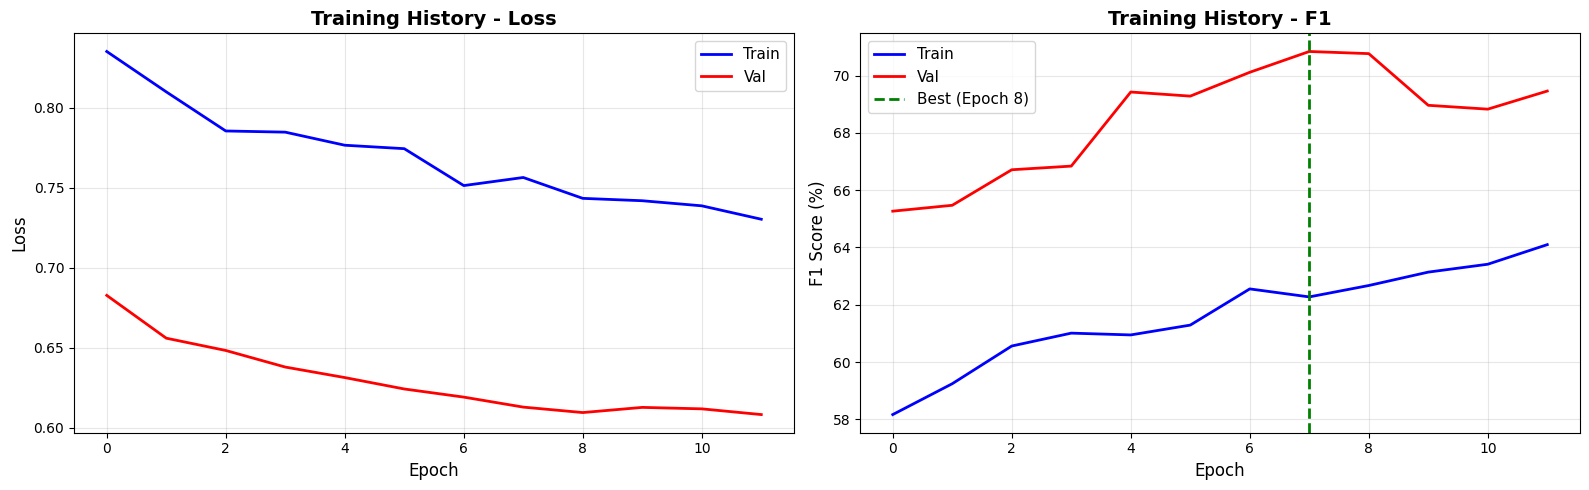

 Training history saved


In [17]:
import matplotlib.pyplot as plt

# Training curves
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Loss
axes[0].plot(history['train_loss'], 'b-', label='Train', linewidth=2)
axes[0].plot(history['val_loss'], 'r-', label='Val', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('Training History - Loss', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# F1
axes[1].plot(history['train_f1'], 'b-', label='Train', linewidth=2)
axes[1].plot(history['val_f1'], 'r-', label='Val', linewidth=2)
axes[1].axvline(x=best_epoch, color='g', linestyle='--', label=f'Best (Epoch {best_epoch+1})', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('F1 Score (%)', fontsize=12)
axes[1].set_title('Training History - F1', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{config.SAVE_DIR}/training_history.png', dpi=300, bbox_inches='tight')
plt.show()

print(" Training history saved")

## Cell 14: Confusion Matrix

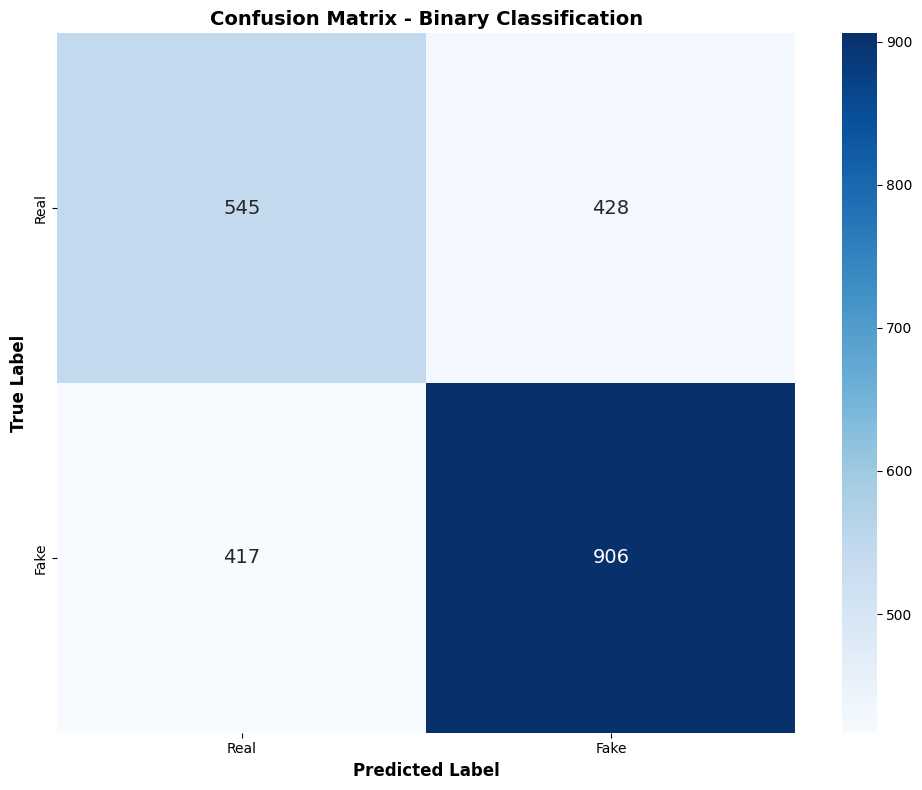

 Confusion matrix saved


In [18]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Confusion matrix
cm = confusion_matrix(test_labels, test_preds)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues', cbar=True,
    xticklabels=['Real', 'Fake'], yticklabels=['Real', 'Fake'],
    ax=ax, annot_kws={'size': 14}
)
ax.set_xlabel('Predicted Label', fontsize=12, fontweight='bold')
ax.set_ylabel('True Label', fontsize=12, fontweight='bold')
ax.set_title('Confusion Matrix - Binary Classification', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{config.SAVE_DIR}/confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print(" Confusion matrix saved")

## Cell 15: ROC Curve

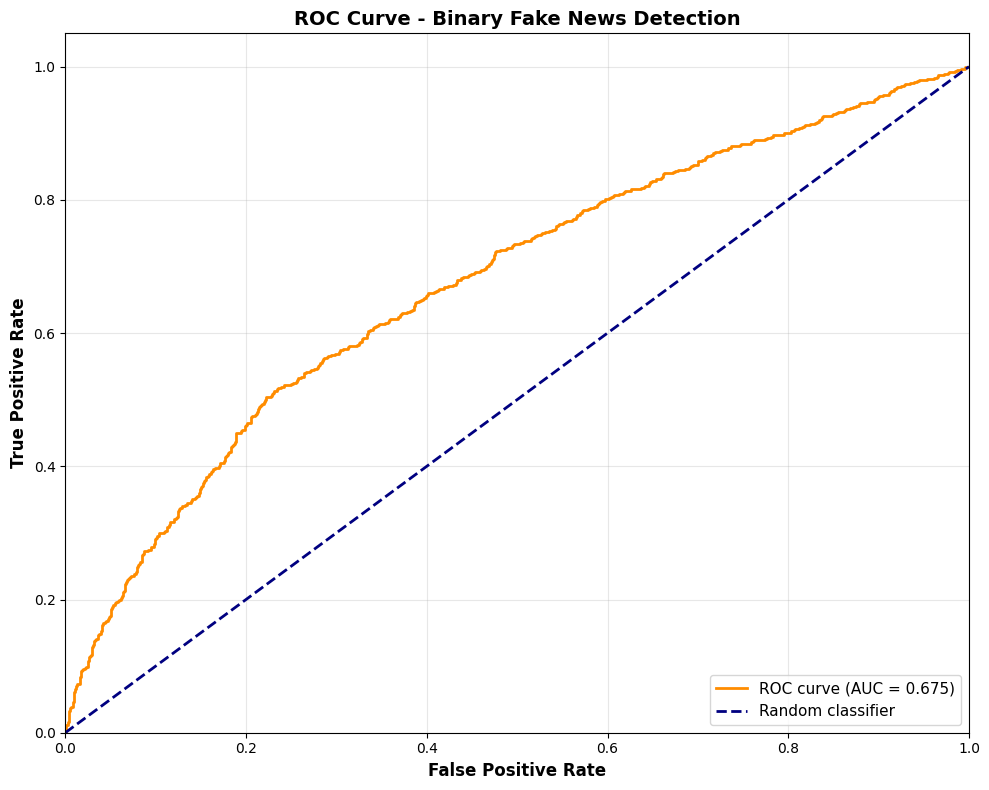

 ROC curve saved (AUC: 0.6747)


In [19]:
import numpy as np
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Get probabilities for ROC
model.eval()
all_probs = []
with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        logits = model(input_ids, attention_mask)
        probs = torch.sigmoid(logits).squeeze().cpu().numpy()
        all_probs.extend(probs if probs.ndim > 0 else [probs])

all_probs = np.array(all_probs)

# ROC curve
fpr, tpr, thresholds = roc_curve(test_labels, all_probs)
roc_auc = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(10, 8))
ax.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
ax.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random classifier')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate', fontsize=12, fontweight='bold')
ax.set_ylabel('True Positive Rate', fontsize=12, fontweight='bold')
ax.set_title('ROC Curve - Binary Fake News Detection', fontsize=14, fontweight='bold')
ax.legend(loc="lower right", fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{config.SAVE_DIR}/roc_curve.png', dpi=300, bbox_inches='tight')
plt.show()

print(f" ROC curve saved (AUC: {roc_auc:.4f})")

## Cell 16: Cross-Validation

In [1]:
from sklearn.model_selection import StratifiedKFold

print(" STRATIFIED K-FOLD CROSS-VALIDATION (k=5)")

# Combine train+val for CV
cv_texts = np.concatenate([df_train['statement'].values, df_val['statement'].values])
cv_labels = np.concatenate([df_train['binary_label'].values, df_val['binary_label'].values])

skf = StratifiedKFold(n_splits=config.N_SPLITS, shuffle=True, random_state=config.SEED)
cv_results = []

for fold, (train_idx, val_idx) in enumerate(skf.split(cv_texts, cv_labels)):
    print(f"Fold {fold+1}/{config.N_SPLITS}...", end=' ')

    fold_train_texts = cv_texts[train_idx]
    fold_train_labels = cv_labels[train_idx]
    fold_val_texts = cv_texts[val_idx]
    fold_val_labels = cv_labels[val_idx]

    # Create datasets
    fold_train_ds = FakeNewsDataset(fold_train_texts, fold_train_labels, tokenizer, config.MAX_LEN)
    fold_val_ds = FakeNewsDataset(fold_val_texts, fold_val_labels, tokenizer, config.MAX_LEN)

    fold_train_loader = DataLoader(fold_train_ds, batch_size=config.BATCH_SIZE, shuffle=True)
    fold_val_loader = DataLoader(fold_val_ds, batch_size=config.BATCH_SIZE*2, shuffle=False)

    # Fresh model
    fold_model = BinaryQuantumFakeNewsDetector(config).to(device)
    fold_optimizer, fold_scheduler = build_optimizer_scheduler(fold_model, fold_train_loader, config)
    fold_criterion = get_loss_function(config)

    best_fold_f1 = 0
    best_fold_wts = None

    # Quick training (10 epochs)
    for ep in range(10):
        train_epoch(fold_model, fold_train_loader, fold_optimizer, fold_scheduler, fold_criterion, config, device)
        _, _, fold_val_f1, _, _ = evaluate(fold_model, fold_val_loader, fold_criterion, device)

        if fold_val_f1 > best_fold_f1:
            best_fold_f1 = fold_val_f1
            best_fold_wts = fold_model.state_dict().copy()

    # Evaluate on test
    fold_model.load_state_dict(best_fold_wts)
    _, test_acc, test_f1, _, _ = evaluate(fold_model, test_loader, fold_criterion, device)

    cv_results.append({'fold': fold+1, 'accuracy': test_acc, 'f1': test_f1})
    print(f"F1: {test_f1:.2f}%")

cv_df = pd.DataFrame(cv_results)

print(f"Mean F1: {cv_df['f1'].mean():.2f}% \u00B1 {cv_df['f1'].std():.2f}%")
print(f"Mean Accuracy: {cv_df['accuracy'].mean():.2f}% \u00B1 {cv_df['accuracy'].std():.2f}%")

 STRATIFIED K-FOLD CROSS-VALIDATION (k=5)


NameError: name 'np' is not defined

## Cell 17: Save Results

In [ ]:
# Save model
checkpoint_path = f'{config.SAVE_DIR}/best_model_binary.pt'
torch.save({
    'model_state_dict': best_model_wts,
    'config': config.__dict__,
    'test_accuracy': test_acc,
    'test_f1': test_f1,
    'history': dict(history),
    'cv_results': cv_results
}, checkpoint_path)

print(f" Model saved to {checkpoint_path}")

# Save summary
results_summary = {
    'timestamp': datetime.now().isoformat(),
    'model': 'BinaryQuantumFakeNewsDetector v1.0',
    'encoder': config.ENCODER_MODEL,
    'test_accuracy': float(test_acc),
    'test_f1': float(test_f1),
    'test_auc': float(roc_auc_score(test_labels, all_probs)),
    'cv_mean_f1': float(cv_df['f1'].mean()),
    'cv_std_f1': float(cv_df['f1'].std()),
    'best_epoch': int(best_epoch),
    'total_epochs': len(history['train_loss'])
}

with open(f'{config.SAVE_DIR}/results_summary.json', 'w') as f:
    json.dump(results_summary, f, indent=4)

print(f" Results summary saved")

## Cell 18: Final Summary

In [ ]:
print(" FINAL SUMMARY - BINARY FAKE NEWS DETECTION")

print(f"""
   MODEL: Binary Quantum Fake News Detector v1.0
   Encoder: {config.ENCODER_MODEL}
   Quantum Qubits: {config.N_QUBITS}
   Quantum Layers: {config.N_QUANTUM_LAYERS}

   TEST SET PERFORMANCE:
   Accuracy:        {test_acc:.2f}%
   F1 Score:        {test_f1:.2f}%
   AUC-ROC:         {roc_auc:.4f}
   Matthews Corr:   {matthews_corrcoef(test_labels, test_preds):.4f}

   CROSS-VALIDATION (5-fold):
   Mean F1: {cv_df['f1'].mean():.2f}% ± {cv_df['f1'].std():.2f}%
   Mean Accuracy: {cv_df['accuracy'].mean():.2f}% ± {cv_df['accuracy'].std():.2f}%

   TRAINING DETAILS:
   Best Epoch: {best_epoch + 1}/{len(history['train_loss'])}
   Best Val F1: {best_val_f1:.2f}%
   Loss Function: {criterion.__class__.__name__}
   Early Stopping: Enabled

   CONFIGURATION:
   Batch Size: {config.BATCH_SIZE}
   Max Sequence Length: {config.MAX_LEN}
   Encoder LR: {config.LR_ENCODER}
   Head LR: {config.LR_HEAD}
   Dropout: {config.DROPOUT_RATE}

""")
print(" EXPERIMENT COMPLETED SUCCESSFULLY!")
